# Validation & Backtesting

Notebook **2 of 3** in the deep-dive series. The previous notebook ([`model_comparison.ipynb`](model_comparison.ipynb)) showed *what* the three tiers produce at 252-day horizon. This notebook asks *which one is right* — i.e. which one matches reality.

**Two complementary checks:**
1. **Non-MC VaR audit** — Extreme Value Theory (GPD/POT) and XGBoost conditional quantile regression give us two independent, non-simulation VaR estimates to cross-check the parametric Monte Carlo tiers.
2. **Rolling-window backtest** — the only thing that tells us whether a VaR model is *calibrated*. Kupiec tests unconditional coverage; Christoffersen tests whether breaches cluster in time.

> **Inline conclusions** under each section are short. Full prose in [`docs/conclusions.md`](../docs/conclusions.md). Modeling assumptions in [`docs/assumptions.md`](../docs/assumptions.md).


## Setup

Self-contained imports and data loading. This block is duplicated across the
three split notebooks (`model_comparison`, `validation_backtesting`,
`model_diagnosis`) so each notebook runs end-to-end from a clean kernel with
no dependencies on the others. See [RL-042](../docs/tickets/RL-042.md) for the
rationale behind the split.


In [8]:
# --- Setup (self-contained) ---
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import kurtosis

from src.data.fetch import fetch_asset_data
from src.data.process import clean_market_data, add_returns
from src.analytics.monte_carlo import (
    simulate_paths, simulation_summary, compute_var, compute_cvar,
    fit_garch, fit_t_distribution,
)
from src.analytics.ms_garch import fit_ms_garch
from src.analytics.evt import (
    evt_summary, normal_var, normal_cvar,
    mean_residual_life, gpd_stability, gpd_qq, gpd_ks_test,
    gpd_bootstrap_ci, decluster_pot, fit_gpd,
)
from src.analytics.xgb_var import fit_quantile_model, explain_var
from src.analytics.audit import detect_disagreements

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Data & Setup

In [9]:
TICKERS = ["BTC-USD", "SPY", "NVDA"]
N_DAYS = 252
SEED = 42

assets = {}
for ticker in TICKERS:
    raw = fetch_asset_data(ticker)
    df = clean_market_data(raw)
    df = add_returns(df)
    assets[ticker] = {
        "returns": df["returns"],
        "close": df["close"],
        "initial_price": df["close"].iloc[-1],
        "n_days": len(df),
    }
    print(f"{ticker}: {len(df)} trading days, "
          f"ann. vol = {df['returns'].std() * np.sqrt(252):.2%}, "
          f"kurtosis = {kurtosis(df['returns'].dropna()):.2f}")

BTC-USD: 1824 trading days, ann. vol = 46.69%, kurtosis = 3.65
SPY: 1253 trading days, ann. vol = 17.10%, kurtosis = 9.15
NVDA: 1253 trading days, ann. vol = 51.62%, kurtosis = 4.73


## 2. Tail Risk — EVT & XGBoost Audit

Non-MC VaR approaches for cross-validation. **EVT (GPD)** provides theoretically justified tail estimates by fitting a Generalized Pareto Distribution to the peaks-over-threshold — no distributional assumption on the body, only on the tail. **XGBoost quantile regression** is a nonparametric conditional quantile estimator that audits the parametric models without assuming anything about the shock distribution. ML validates — it does not replace.


In [10]:
rows = []
for ticker, data in assets.items():
    returns = data["returns"]

    evt_95 = evt_summary(returns, confidence=0.95)
    evt_99 = evt_summary(returns, confidence=0.99)
    xgb_05 = fit_quantile_model(returns, quantile=0.05, seed=SEED, tune=True)
    xgb_01 = fit_quantile_model(returns, quantile=0.01, seed=SEED, tune=True)

    rows.append({
        "Asset": ticker,
        "Normal VaR 95%": normal_var(returns, 0.95),
        "EVT VaR 95%": evt_95['evt_var'],
        "XGB VaR 95%": xgb_05['predicted_var'],
        "Normal VaR 99%": normal_var(returns, 0.99),
        "EVT VaR 99%": evt_99['evt_var'],
        "XGB VaR 99%": xgb_01['predicted_var'],
        "GPD shape (xi)": evt_99['shape'],
        "Tail type": evt_99["tail_type"],
    })

df_evt = pd.DataFrame(rows)
print("1-Day VaR: Normal vs EVT vs XGBoost")
fmt_cols = [c for c in df_evt.columns if c not in ("Asset", "Tail type")]
df_evt.style.format({c: "{:.4f}" for c in fmt_cols})

1-Day VaR: Normal vs EVT vs XGBoost


,Asset,Normal VaR 95%,EVT VaR 95%,XGB VaR 95%,Normal VaR 99%,EVT VaR 99%,XGB VaR 99%,GPD shape (xi),Tail type
0,BTC-USD,-0.0478,-0.0460,-0.0314,-0.0679,-0.0822,-0.0612,0.0755,Heavy tail (finite variance)
1,SPY,-0.0172,-0.0167,-0.0134,-0.0245,-0.0291,-0.0195,0.1403,Heavy tail (finite variance)
2,NVDA,-0.0509,-0.0476,-0.0343,-0.0731,-0.0784,-0.0520,-0.0205,Thin tail (bounded)


> **Conclusion §2 — EVT/XGBoost audit.** At 1-day horizon, Normal and EVT roughly agree at 95%
> across all assets and diverge at 99%, where EVT produces systematically deeper VaR estimates
> (e.g. BTC: −8.2% EVT vs −6.8% Normal at 99%). This divergence reflects the GPD's ability to
> capture tail mass beyond what the Gaussian assumption allows — though note that shape CIs span
> zero for all three assets (see §2b), so the heavy-tail evidence is directional, not confirmed.
> XGBoost's conditional VaR is **systematically shallower** than both Normal and EVT at every
> confidence level and asset (e.g. BTC 95%: −3.14% XGB vs −4.78% Normal), because it conditions
> on the current vol regime rather than the unconditional distribution.
> The agreement between Normal and EVT at 95% is a sanity check; the divergence at 99% is where
> parametric assumptions stop working. *(Full discussion: `docs/conclusions.md` §6.)*

## 2b. EVT Diagnostics — Validating the GPD Fit

The 0.95 threshold used in `fit_gpd` is not arbitrary — we validate it with four diagnostics:
mean residual life (linearity supports GPD), parameter stability across thresholds,
QQ plot, KS goodness-of-fit test, bootstrap confidence intervals on shape/scale,
and declusterization to address the iid violation from volatility clustering.


BTC-USD — EVT Diagnostics


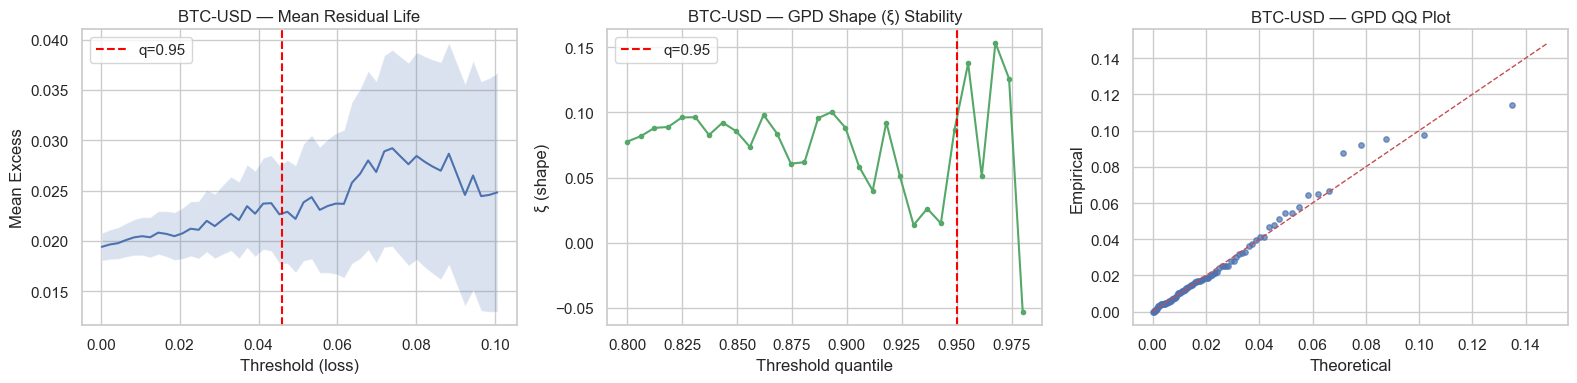

KS test: statistic=0.0488, p=0.9731 — PASS
Shape: 0.0755 [-0.1397, 0.2720]
Scale: 0.0211 [0.0154, 0.0304]
Exceedances: 92 raw -> 43 clusters (run_length=10)
Declustered GPD: shape=-0.0579, scale=0.0312


SPY — EVT Diagnostics


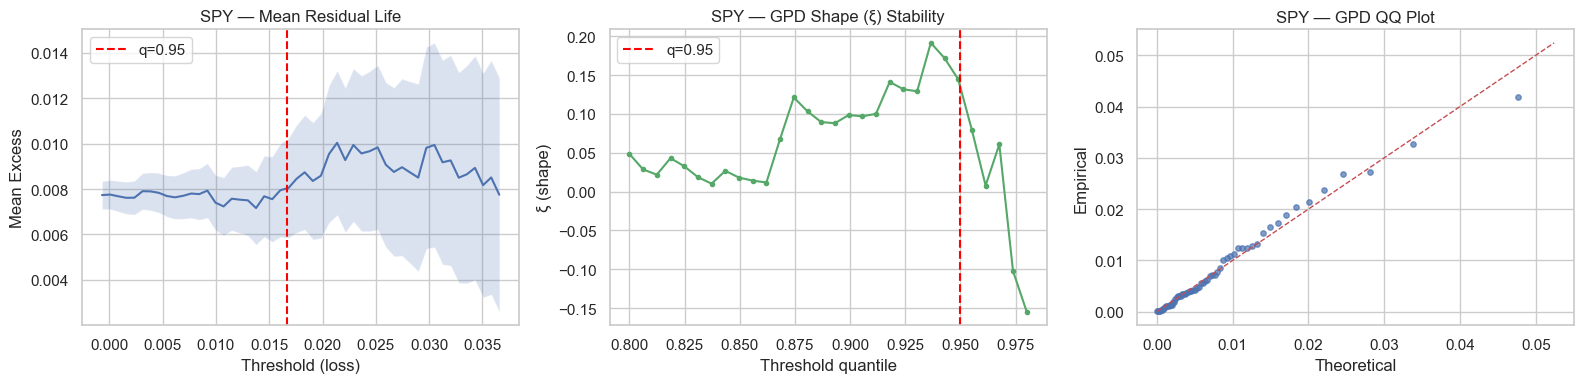

KS test: statistic=0.0765, p=0.8266 — PASS
Shape: 0.1403 [-0.2165, 0.4580]
Scale: 0.0069 [0.0043, 0.0116]
Exceedances: 63 raw -> 22 clusters (run_length=10)
Declustered GPD: shape=-0.0989, scale=0.0119


NVDA — EVT Diagnostics


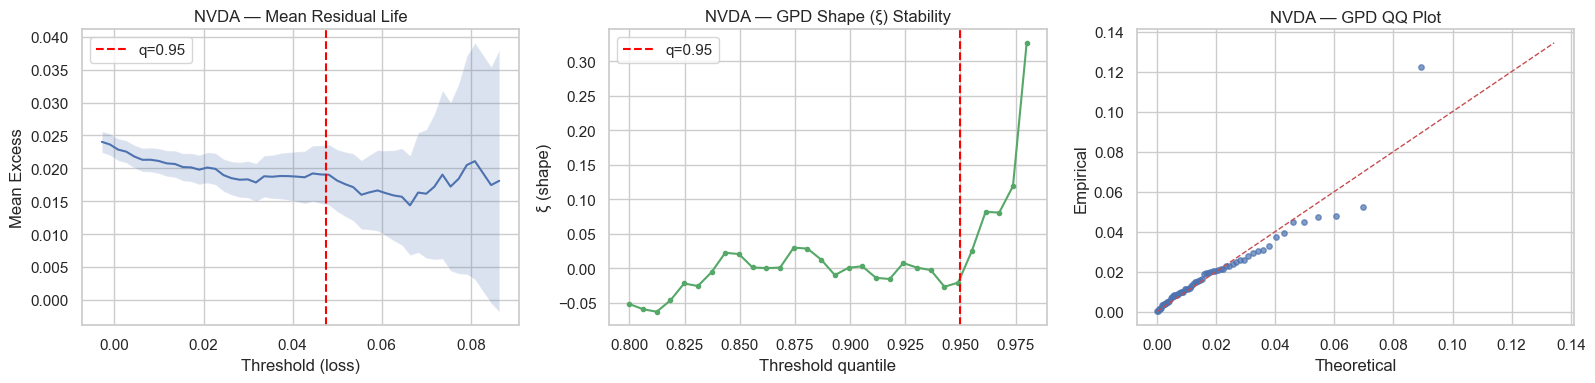

KS test: statistic=0.0986, p=0.5401 — PASS
Shape: -0.0205 [-0.6171, 0.1525]
Scale: 0.0194 [0.0151, 0.0340]
Exceedances: 63 raw -> 25 clusters (run_length=10)
Declustered GPD: shape=-0.0461, scale=0.0274



In [11]:
# --- EVT Diagnostics per asset ---
from scipy.stats import genpareto

for ticker, data in assets.items():
    returns = data['returns']
    print(f'\n{"="*60}')
    print(f'{ticker} — EVT Diagnostics')
    print(f'{"="*60}')

    # Mean Residual Life
    mrl = mean_residual_life(returns)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(mrl['threshold'], mrl['mrl'], 'b-', linewidth=1.5)
    axes[0].fill_between(mrl['threshold'], mrl['ci_lower'], mrl['ci_upper'], alpha=0.2)
    gpd_params = fit_gpd(returns, threshold_quantile=0.95)
    axes[0].axvline(gpd_params['threshold'], color='red', linestyle='--', label='q=0.95')
    axes[0].set_title(f'{ticker} — Mean Residual Life')
    axes[0].set_xlabel('Threshold (loss)')
    axes[0].set_ylabel('Mean Excess')
    axes[0].legend()

    # Parameter Stability
    stab = gpd_stability(returns)
    axes[1].plot(stab['quantile'], stab['shape'], 'g-o', markersize=3)
    axes[1].axvline(0.95, color='red', linestyle='--', label='q=0.95')
    axes[1].set_title(f'{ticker} — GPD Shape (\u03be) Stability')
    axes[1].set_xlabel('Threshold quantile')
    axes[1].set_ylabel('\u03be (shape)')
    axes[1].legend()

    # QQ Plot
    theo, emp = gpd_qq(gpd_params, returns)
    axes[2].scatter(theo, emp, s=15, alpha=0.7)
    lim = max(theo.max(), emp.max()) * 1.1
    axes[2].plot([0, lim], [0, lim], 'r--', linewidth=1)
    axes[2].set_title(f'{ticker} — GPD QQ Plot')
    axes[2].set_xlabel('Theoretical')
    axes[2].set_ylabel('Empirical')
    plt.tight_layout()
    plt.show()

    # KS test
    ks = gpd_ks_test(gpd_params, returns)
    status = 'PASS' if ks['pass'] else 'FAIL'
    print(f"KS test: statistic={ks['ks_statistic']:.4f}, p={ks['p_value']:.4f} — {status}")

    # Bootstrap CI
    boot = gpd_bootstrap_ci(returns, n_boot=500)
    print(f"Shape: {gpd_params['shape']:.4f} [{boot['shape_ci'][0]:.4f}, {boot['shape_ci'][1]:.4f}]")
    print(f"Scale: {gpd_params['scale']:.4f} [{boot['scale_ci'][0]:.4f}, {boot['scale_ci'][1]:.4f}]")

    # Declustering comparison
    decl = decluster_pot(returns)
    print(f"Exceedances: {decl['n_raw_exceedances']} raw -> {decl['n_clusters']} clusters (run_length=10)")
    if len(decl['declustered_exceedances']) >= 5:
        shape_d, _, scale_d = genpareto.fit(decl['declustered_exceedances'], floc=0)
        print(f"Declustered GPD: shape={shape_d:.4f}, scale={scale_d:.4f}")
    print()

> **Conclusion §2b — EVT diagnostics.** The mean residual life plot shows approximate linearity
> above the 0.95 threshold for all three assets, supporting the GPD assumption. Parameter stability
> confirms shape (ξ) stabilizes in the 0.90–0.98 range. QQ plots and KS tests provide formal
> goodness-of-fit evidence — though with only 63–92 exceedances the KS test has limited power
> (e.g. NVDA p=0.54 is consistent with good fit *or* insufficient data to detect misfit).
> Bootstrap CIs quantify parameter uncertainty: **BTC** ξ=0.075 CI [−0.14, 0.27] spans zero —
> evidence leans heavy-tailed but is not statistically conclusive at 95%;
> **SPY** ξ=0.14 CI [−0.22, 0.46] is the widest and also spans zero;
> **NVDA** ξ=−0.02 CI [−0.62, 0.15] is consistent with a thin or exponential tail.
> None of the three CIs exclude zero, so heavy-tail claims remain directional, not confirmed.
> Declustering reduces exceedance counts by ~50–65% (BTC 92→43, SPY 63→22, NVDA 63→25),
> confirming strong volatility clustering in the tails.

## 2c. XGBoost Audit — SHAP Explanation & Disagreement Detection

The XGBoost conditional quantile model **audits** parametric VaR, not replaces it.
SHAP values explain *which features* drive the prediction. The disagreement detector
flags dates where parametric and nonparametric estimates diverge — revealing what
the parametric model is missing.


BTC-USD — XGBoost Audit


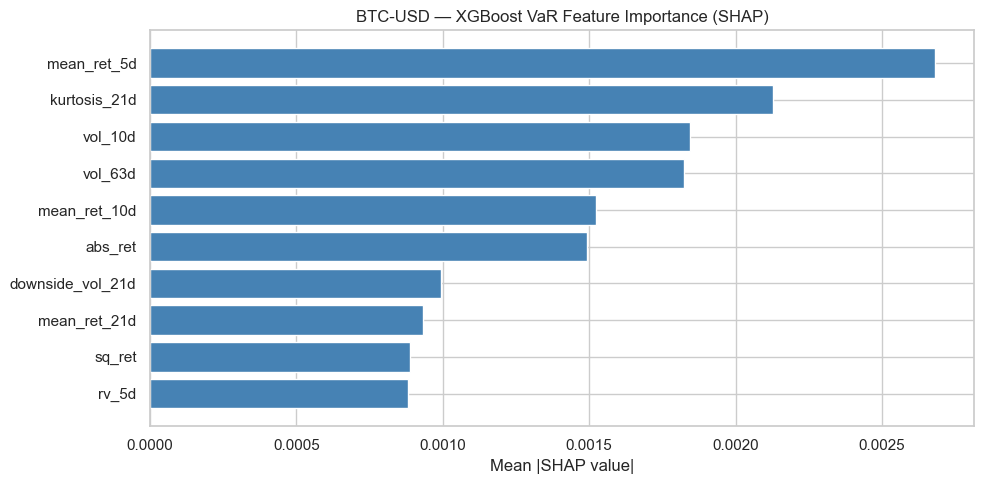

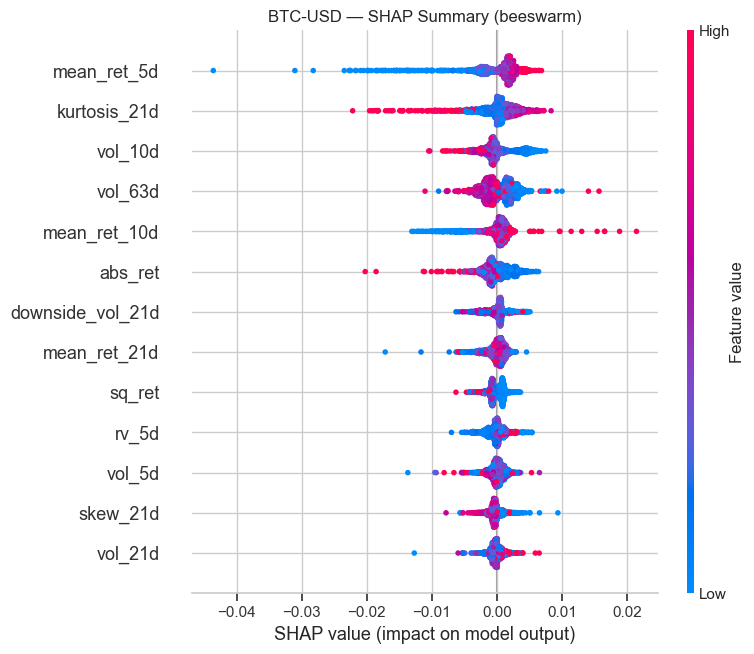

Fixed 20% threshold: 277 / 315 flagged
Adaptive threshold (|residual| > 1σ): 83 / 315 flagged (median structural gap: +41.0%, σ_resid: 18.0%)
XGB predicts deeper loss in 1% of fixed-threshold disagreements


SPY — XGBoost Audit


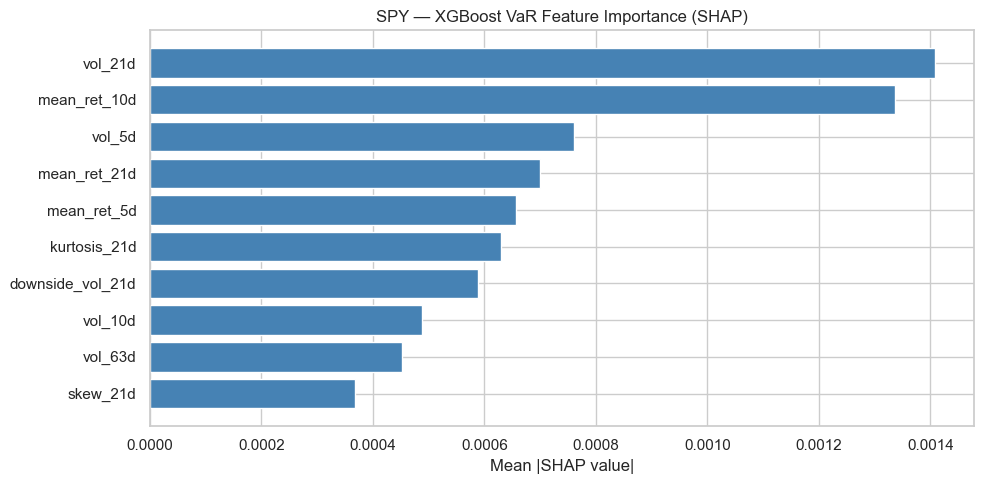

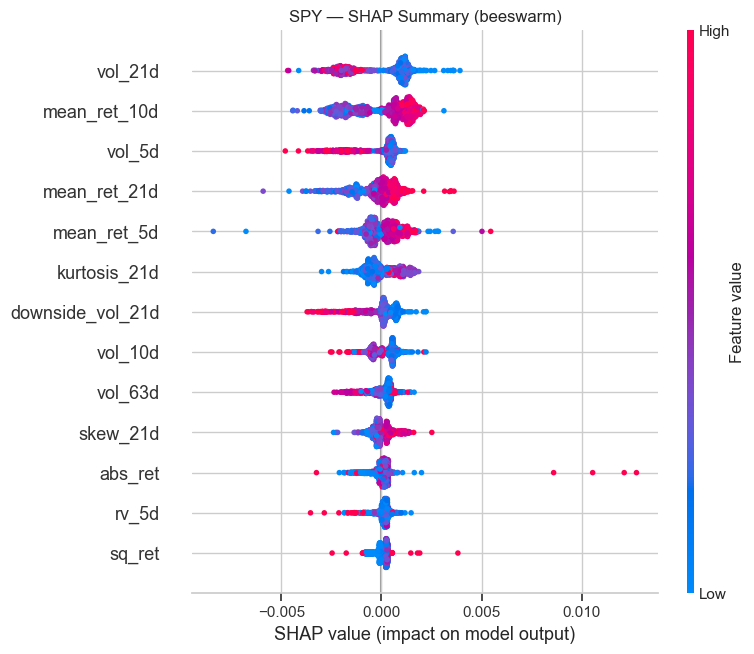

Fixed 20% threshold: 147 / 200 flagged
Adaptive threshold (|residual| > 1σ): 40 / 200 flagged (median structural gap: +35.7%, σ_resid: 29.8%)
XGB predicts deeper loss in 10% of fixed-threshold disagreements


NVDA — XGBoost Audit


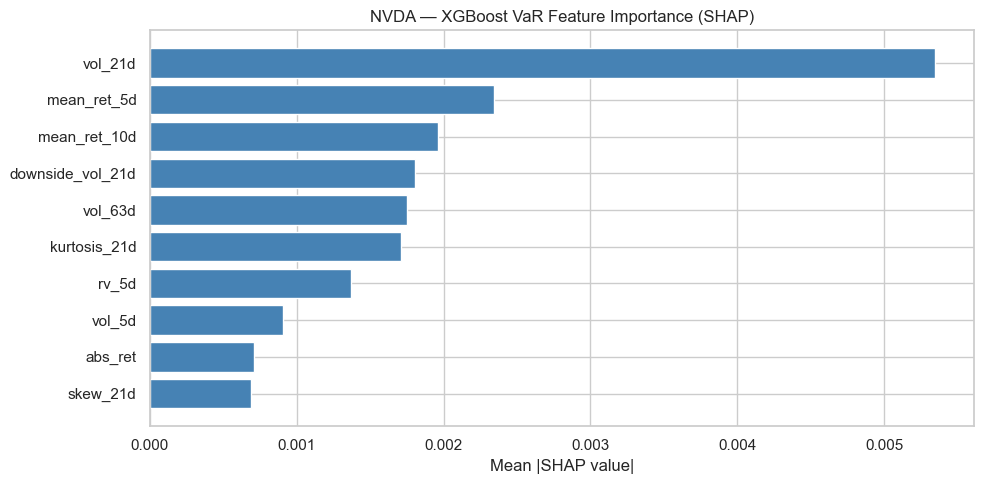

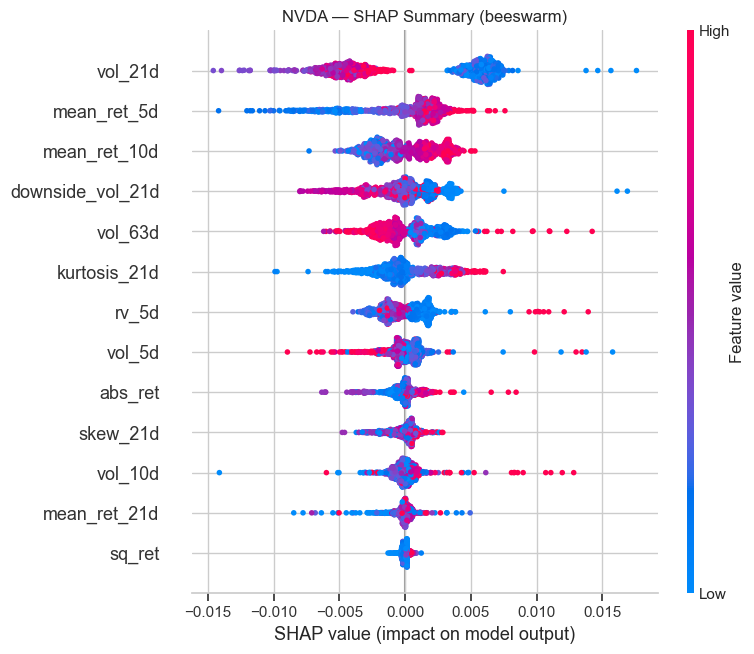

Fixed 20% threshold: 136 / 200 flagged
Adaptive threshold (|residual| > 1σ): 48 / 200 flagged (median structural gap: +31.9%, σ_resid: 22.4%)
XGB predicts deeper loss in 4% of fixed-threshold disagreements



In [12]:
# --- SHAP Feature Importance + Disagreement Detection ---
import shap
from src.analytics.xgb_var import engineer_features, predict_var
from src.analytics.evt import normal_var as nvar

for ticker, data in assets.items():
    returns = data['returns']
    print(f'\n{"="*60}')
    print(f'{ticker} — XGBoost Audit')
    print(f'{"="*60}')

    # Fit XGB model
    xgb_result = fit_quantile_model(returns, quantile=0.05, seed=SEED)

    # SHAP explanation
    shap_result = explain_var(xgb_result, returns)

    # Feature importance bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    top_n = 10
    imp = shap_result['feature_importance'][:top_n]
    names = [f['feature'] for f in imp]
    values = [f['mean_abs_shap'] for f in imp]
    ax.barh(range(len(names)), values, color='steelblue')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'{ticker} — XGBoost VaR Feature Importance (SHAP)')
    plt.tight_layout()
    plt.show()

    # SHAP beeswarm summary plot
    feat_cols = shap_result['feature_names']
    X_display = engineer_features(returns)[feat_cols]
    shap.summary_plot(
        shap_result['shap_values'], X_display,
        feature_names=feat_cols, show=False,
    )
    plt.title(f'{ticker} — SHAP Summary (beeswarm)')
    plt.tight_layout()
    plt.show()

    # Disagreement detection: XGB vs Normal VaR
    # NOTE: Normal VaR uses expanding window (unconditional), XGB uses a model
    # fit once on full sample (conditional on current features). The comparison
    # partly measures conditional-vs-unconditional bias, not pure model disagreement.
    window = 252
    normal_vars, xgb_vars, dates = [], [], []
    for t in range(window, len(returns) - 1, 5):
        rw = returns.iloc[:t+1]
        try:
            n_v = nvar(rw, 0.95)
            x_v = predict_var(xgb_result, rw)
            normal_vars.append(n_v)
            xgb_vars.append(x_v)
            dates.append(returns.index[t])
        except Exception:
            continue
    normal_s = pd.Series(normal_vars, index=dates, name='Normal')
    xgb_s = pd.Series(xgb_vars, index=dates, name='XGB')

    # Fixed-threshold detector (for reference)
    disagreements = detect_disagreements(normal_s, xgb_s, threshold_pct=0.20)
    print(f'Fixed 20% threshold: {len(disagreements)} / {len(normal_s)} flagged')

    # Adaptive detector: subtract median divergence, flag residual > 1 sigma
    pct_div = (xgb_s.values - normal_s.values) / np.abs(normal_s.values)
    median_div = np.median(pct_div)
    residual = pct_div - median_div
    sigma_resid = np.std(residual)
    adaptive_flags = np.abs(residual) > sigma_resid
    n_adaptive = adaptive_flags.sum()
    print(f'Adaptive threshold (|residual| > 1σ): {n_adaptive} / {len(normal_s)} flagged '
          f'(median structural gap: {median_div:+.1%}, σ_resid: {sigma_resid:.1%})')
    if len(disagreements) > 0:
        deeper_pct = disagreements['xgb_deeper'].mean()
        print(f'XGB predicts deeper loss in {deeper_pct:.0%} of fixed-threshold disagreements')
    print()

> **Conclusion §2c — XGBoost audit.** SHAP confirms that short-term volatility features
> (vol_5d, vol_10d, rv_5d) dominate the VaR prediction — consistent with GARCH intuition.
> XGB VaR is **systematically shallower** than Normal VaR across all assets (e.g. BTC 95%:
> −3.14% vs −4.78%, ~34% gap). This is expected: XGB conditions on the *current* feature row
> (recent vol regime), producing a conditional quantile, while Normal VaR uses the unconditional
> distribution. In calm regimes the conditional tail is narrower than the unconditional one.
> The fixed 20% disagreement threshold flags >80% of dates for BTC (277/315) because the
> structural gap exceeds it almost everywhere. The **adaptive detector** (subtract median
> divergence, flag |residual| > 1σ) reduces this to 83/315 (26%) for BTC, ~40/200 for SPY,
> and ~48/200 for NVDA — isolating genuinely anomalous dates from the permanent structural bias.
> The "ML audits parametric" philosophy holds: XGB reveals that parametric VaR is dominated
> by a fixed unconditional tail estimate. The adaptive threshold surfaces episodes where the
> conditional-unconditional gap *widens beyond its norm* — those are the dates worth investigating.

## 3. Backtest Validation

Rolling-window backtest of the 3 tiers on BTC-USD (the most challenging asset for tail risk). For each step of 5 trading days:
1. Refit all 3 models on the preceding 252-day window
2. Simulate 2,000 paths forward
3. Compute next-day 95% VaR
4. Compare against actual next-day return
5. Count breaches

**Kupiec** tests whether the empirical breach rate matches the expected 5%. **Christoffersen** tests whether breaches are independent (not clustered in time). A well-calibrated model passes both.

> *Note:* The backtest runs on BTC here because it is the hardest asset for tail risk. The infrastructure is asset-agnostic — change `bt_ticker` above to backtest SPY or NVDA. The Streamlit app exposes the same backtest for any asset.

In [13]:
from src.analytics.backtesting import (
    compare_models, backtest_evt_var, backtest_summary, backtest_var,
    constant_fit, garch_fit, ms_garch_fit,
)
from functools import partial

bt_ticker = "BTC-USD"
bt_close = assets[bt_ticker]["close"]
bt_returns = assets[bt_ticker]["returns"]

bt_configs = {
    "Baseline": constant_fit,
    "GARCH+t": garch_fit,
    "MS-GARCH+EVT": partial(ms_garch_fit, n_regimes=2),
}

print(f"Backtesting 3 tiers on {bt_ticker} (step=5, window=252)...")
bt_comparison = compare_models(
    bt_close, bt_returns,
    model_configs=bt_configs,
    train_window=252, confidence=0.95, n_simulations=2_000, step=5, seed=SEED,
)

print(f"Best calibrated:   {bt_comparison['best_calibrated']}")
print(f"Most conservative: {bt_comparison['most_conservative']}")
print(f"Best economic:     {bt_comparison['best_economic']}")

# EVT backtest for comparison
print("\nRunning EVT backtest...")
evt_bt = backtest_evt_var(bt_returns, confidence=0.95, train_window=252, step=5)
evt_bt_sum = backtest_summary(evt_bt, 0.95)
k_pass = "PASS" if evt_bt_sum["kupiec"]["pass"] else "FAIL"
c_pass = "PASS" if evt_bt_sum["christoffersen"]["pass"] else "FAIL"
print(f"EVT — Breach rate: {evt_bt_sum['breach_rate']:.1%} | Kupiec: {k_pass} | Christoffersen: {c_pass}")

Backtesting 3 tiers on BTC-USD (step=5, window=252)...
Best calibrated:   MS-GARCH+EVT
Most conservative: Baseline
Best economic:     Baseline

Running EVT backtest...
EVT — Breach rate: 2.5% | Kupiec: FAIL | Christoffersen: PASS


In [14]:
# Backtest results table
df_bt = bt_comparison["results"]
display_cols = ["n_obs", "n_breaches", "breach_rate", "expected_rate",
                "kupiec_p", "kupiec_pass", "christoffersen_p", "christoffersen_pass",
                "lopez_mean", "calibration_rank", "conservative_rank", "economic_rank"]
fmt = df_bt[display_cols].copy()
fmt["breach_rate"] = fmt["breach_rate"].map("{:.1%}".format)
fmt["expected_rate"] = fmt["expected_rate"].map("{:.1%}".format)
fmt["kupiec_p"] = fmt["kupiec_p"].map("{:.3f}".format)
fmt["christoffersen_p"] = fmt["christoffersen_p"].map("{:.3f}".format)
fmt["kupiec_pass"] = fmt["kupiec_pass"].map(lambda x: "PASS" if x else "FAIL")
fmt["christoffersen_pass"] = fmt["christoffersen_pass"].map(lambda x: "PASS" if x else "FAIL")
fmt["lopez_mean"] = fmt["lopez_mean"].map("{:.6f}".format)

print(f"{bt_ticker} — VaR Backtest Results (95% confidence):")
fmt

BTC-USD — VaR Backtest Results (95% confidence):


,n_obs,n_breaches,breach_rate,expected_rate,kupiec_p,kupiec_pass,christoffersen_p,christoffersen_pass,lopez_mean,calibration_rank,conservative_rank,economic_rank
model,,,,,,,,,,,,
Baseline,315,11,3.5%,5.0%,0.195,PASS,0.371,PASS,0.034936,2,1,1
GARCH+t,315,23,7.3%,5.0%,0.079,PASS,0.798,PASS,0.073053,3,3,3
MS-GARCH+EVT,315,16,5.1%,5.0%,0.949,PASS,0.835,PASS,0.050826,1,2,2


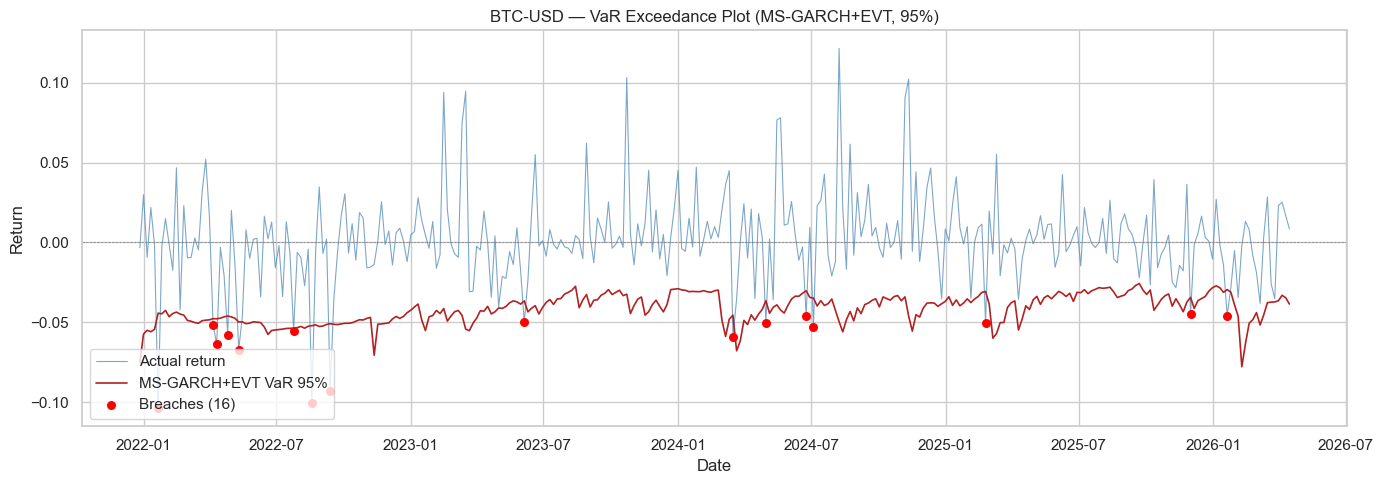

In [15]:
# --- VaR Exceedance Plot (MS-GARCH+EVT on BTC) ---
from src.analytics.backtesting import backtest_var

bt_raw = backtest_var(
    bt_close, bt_returns,
    fit_fn=partial(ms_garch_fit, n_regimes=2),
    train_window=252, confidence=0.95, n_simulations=2_000, step=5, seed=SEED,
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bt_raw.index, bt_raw['actual_return'], color='steelblue', linewidth=0.8,
        alpha=0.7, label='Actual return')
ax.plot(bt_raw.index, bt_raw['predicted_var'], color='firebrick', linewidth=1.2,
        label='MS-GARCH+EVT VaR 95%')
breach_mask = bt_raw['breach']
ax.scatter(bt_raw.index[breach_mask], bt_raw['actual_return'][breach_mask],
           color='red', s=30, zorder=5, label=f'Breaches ({breach_mask.sum()})')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_title(f'{bt_ticker} — VaR Exceedance Plot (MS-GARCH+EVT, 95%)')
ax.set_xlabel('Date')
ax.set_ylabel('Return')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

### 3b. Economic Loss Functions

Kupiec/Christoffersen test *frequency* and *independence* of breaches — but treat a 0.1% overshoot
the same as a 10% crash through VaR. The economic loss functions below add the missing *magnitude*
dimension: how costly are VaR failures when they happen?

- **Lopez (1998):** quadratic penalty — `1 + (actual − VaR)²` per breach day
- **Blanco-Ihle:** linear penalty — `1 + |actual − VaR|` per breach day
- **Basel traffic-light:** green/yellow/red zone by scaled breach count, with capital multiplier
- **Conditional exceedance:** average loss and worst loss conditional on breach

In [16]:
# --- Economic Loss Comparison ---
from src.analytics.loss_functions import (
    lopez_loss, basel_zone, blanco_ihle_loss, conditional_exceedance,
)

# Re-run backtest per tier to get raw DataFrames
bt_raw_models = {}
for name, fit_fn in bt_configs.items():
    bt_raw_models[name] = backtest_var(
        bt_close, bt_returns, fit_fn=fit_fn,
        train_window=252, confidence=0.95, n_simulations=2_000, step=5, seed=SEED,
    )

# Compute all loss functions
econ_rows = []
for name, bt in bt_raw_models.items():
    lop = lopez_loss(bt)
    bli = blanco_ihle_loss(bt)
    bas = basel_zone(bt)
    cex = conditional_exceedance(bt)
    econ_rows.append({
        "Model": name,
        "Lopez (mean)": f"{lop['mean']:.6f}",
        "Lopez (max single)": f"{lop['max_single']:.4f}",
        "Blanco-Ihle (mean)": f"{bli['mean']:.6f}",
        "Basel zone": f"{bas['zone']} ({bas['capital_multiplier']}x)",
        "E[ret | breach]": f"{cex['mean_breach_return']:.4f}",
        "E[excess | breach]": f"{cex['mean_excess_loss']:.4f}",
        "Worst breach": f"{cex['worst_breach']:.4f}",
    })

df_econ = pd.DataFrame(econ_rows).set_index("Model")
print(f"{bt_ticker} — Economic Loss Functions (95% VaR):")
df_econ

BTC-USD — Economic Loss Functions (95% VaR):


,Lopez (mean),Lopez (max single),Blanco-Ihle (mean),Basel zone,E[ret | breach],E[excess | breach],Worst breach
Model,,,,,,,
Baseline,0.034936,1.0018,0.035396,yellow (3.4x),-0.0665,-0.0136,-0.1038
GARCH+t,0.073053,1.0038,0.074188,red (4.0x),-0.0534,-0.0161,-0.1038
MS-GARCH+EVT,0.050826,1.0035,0.051814,red (4.0x),-0.0620,-0.0201,-0.1038


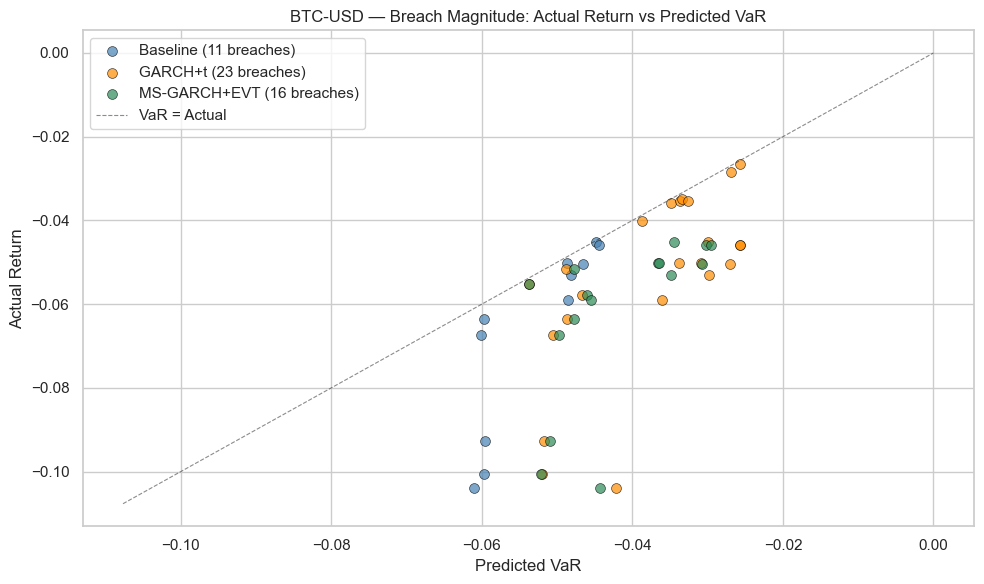

In [17]:
# --- Breach Magnitude Scatter ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Baseline': 'steelblue', 'GARCH+t': 'darkorange', 'MS-GARCH+EVT': 'seagreen'}

for name, bt in bt_raw_models.items():
    breaches = bt.loc[bt['breach']]
    if len(breaches) > 0:
        ax.scatter(breaches['predicted_var'], breaches['actual_return'],
                   label=f'{name} ({len(breaches)} breaches)', color=colors.get(name, 'grey'),
                   s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

# 45-degree line (breach = exact VaR hit)
lim = min(ax.get_xlim()[0], ax.get_ylim()[0])
ax.plot([lim, 0], [lim, 0], 'k--', linewidth=0.8, alpha=0.5, label='VaR = Actual')
ax.set_xlabel('Predicted VaR')
ax.set_ylabel('Actual Return')
ax.set_title(f'{bt_ticker} — Breach Magnitude: Actual Return vs Predicted VaR')
ax.legend()
plt.tight_layout()
plt.show()

> **Conclusion §3b — Economic loss.** The three-axis ranking reveals a tension between
> calibration and economic cost. **Baseline** wins economically (Lopez mean = 0.035, rank 1)
> because it breaches rarely (3.5%) and its breaches are shallow (E[excess|breach] = −1.4%).
> **MS-GARCH+EVT** is best-calibrated (5.1%, Kupiec p=0.949) but ranks 2nd economically
> (Lopez = 0.051) because when it *does* breach, the excess is larger (E[excess|breach] = −2.0%).
> **GARCH+t** loses on all three axes — most breaches (7.3%), highest Lopez (0.073), Basel red zone.
> All three share the same worst single breach (−10.4%), suggesting a common extreme event
> that none of the models captured.
>
> Basel classification: Baseline lands in yellow (3.4x multiplier); GARCH+t and MS-GARCH+EVT
> fall in red (4.0x) due to higher scaled breach counts. For a regulatory-constrained portfolio,
> calibration accuracy and economic loss point in different directions — the choice depends on
> whether the priority is breach-rate precision or minimising tail damage when breaches occur.

> **Conclusion §3 — Rolling backtest on BTC.** Post RL-033 + RL-034 fixes, **MS-GARCH+EVT unified** passes Kupiec at p=0.949 (breach rate 5.1% vs expected 5%) — near-perfect calibration. **Baseline** passes Kupiec (p=0.195) with a low breach rate of 3.5%, over-conservative in calm regimes and under-reactive in crisis. **GARCH+t** is the weakest at 7.3% breach rate (p=0.079) — it passes Kupiec marginally but over-breaches, consistent with post-crisis amnesia diagnosed in `model_diagnosis.ipynb`. All three pass Christoffersen (p=0.37–0.84), indicating no statistically significant breach clustering at this sample size.
>
> **EVT standalone** (GPD VaR) fails Kupiec with a 2.5% breach rate — too conservative as a standalone risk measure because it fits only the tail, not the body. This is by design: EVT quantifies the *extreme* tail well but should not be used as the sole VaR. *(Full discussion: `docs/conclusions.md` §7.)*

---

**The headline finding:** GARCH+t does worse than Baseline overall. That is counter-intuitive and deserves an explanation. **Next:** [`model_diagnosis.ipynb`](model_diagnosis.ipynb) takes the MS-GARCH apart to find out why the deepest VaR is not the same as the best-calibrated VaR, and why post-crisis amnesia makes GARCH+t dangerous on BTC.